In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

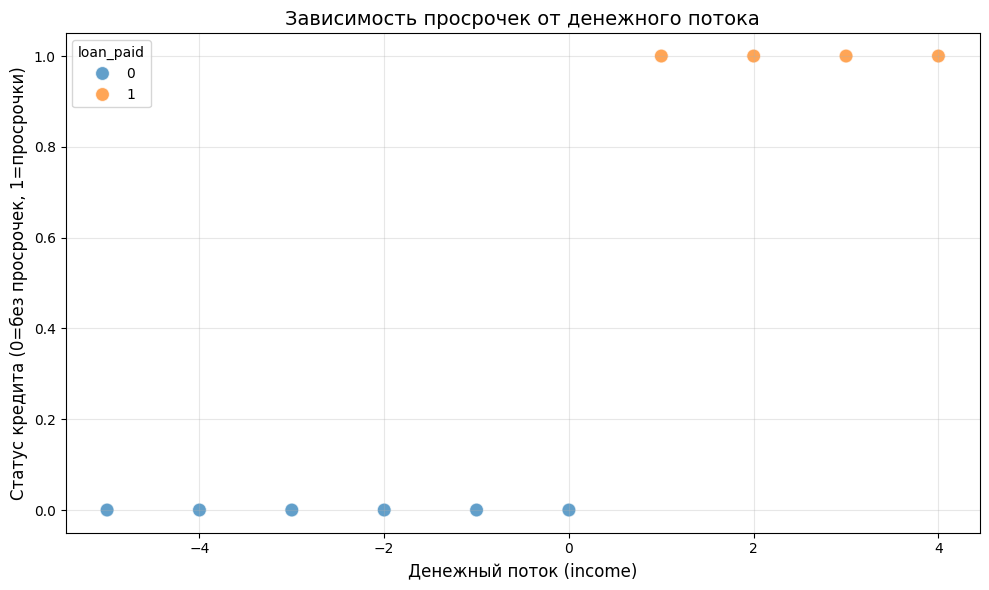

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Пример данных
data = pd.DataFrame({
    'income': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4],
    'loan_paid': [0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='income', y='loan_paid', 
                hue='loan_paid',
                s=100, alpha=0.7)

plt.xlabel('Денежный поток (income)', fontsize=12)
plt.ylabel('Статус кредита (0=без просрочек, 1=просрочки)', fontsize=12)
plt.title('Зависимость просрочек от денежного потока', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### **Работа с выбросами (Outliers)**

In [2]:
# Указываем среднее значение, среднеквадратическое отклонение и количество сэмплов

def create_ages(mu=50,sigma=13,num_samples=100,seed=42):

    # Указываем значение random seed в той же ячейке, что и вызов метода random - 
    # это нужно для того, чтобы получить те же самые данные
    # Мы используем значение 42 (42 это число из комедийного сериала Автостопом по Галактике - 
    # Hitchhiker's Guide to the Galaxy)
    np.random.seed(seed)

    sample_ages = np.random.normal(loc=mu,scale=sigma,size=num_samples)
    sample_ages = np.round(sample_ages,decimals=0)
    
    return sample_ages

In [3]:
sample = create_ages()

In [4]:
sample

array([56., 48., 58., 70., 47., 47., 71., 60., 44., 57., 44., 44., 53.,
       25., 28., 43., 37., 54., 38., 32., 69., 47., 51., 31., 43., 51.,
       35., 55., 42., 46., 42., 74., 50., 36., 61., 34., 53., 25., 33.,
       53., 60., 52., 48., 46., 31., 41., 44., 64., 54., 27., 54., 45.,
       41., 58., 63., 62., 39., 46., 54., 63., 44., 48., 36., 34., 61.,
       68., 49., 63., 55., 42., 55., 70., 50., 70., 16., 61., 51., 46.,
       51., 24., 47., 55., 69., 43., 39., 43., 62., 54., 43., 57., 51.,
       63., 41., 46., 45., 31., 54., 53., 50., 47.])

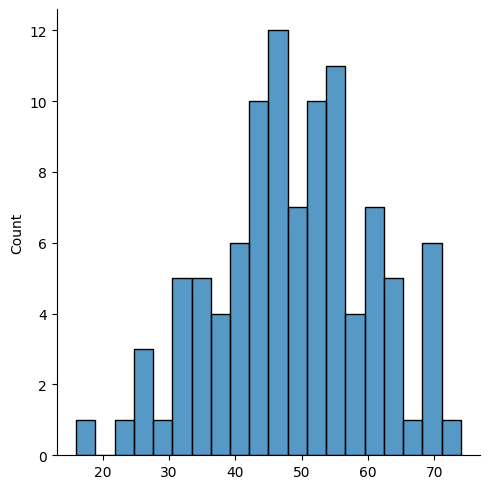

In [5]:
sns.displot(data=sample, bins=20)

<Axes: >

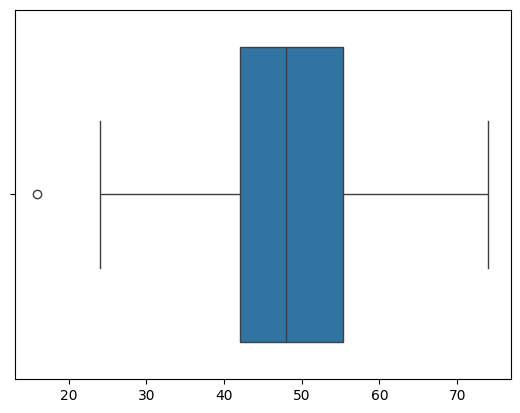

In [8]:
sns.boxplot(x=sample)

In [9]:
ser = pd.Series(sample)
ser

0     56.0
1     48.0
2     58.0
3     70.0
4     47.0
      ... 
95    31.0
96    54.0
97    53.0
98    50.0
99    47.0
Length: 100, dtype: float64

In [10]:
ser.describe()

count    100.00000
mean      48.66000
std       11.82039
min       16.00000
25%       42.00000
50%       48.00000
75%       55.25000
max       74.00000
dtype: float64

In [11]:
IQR = 55.25000 - 42.00000

In [12]:
lower_limit = 42.00000 - 1.5 * IQR
lower_limit

22.125

In [14]:
ser[ser > lower_limit]

0     56.0
1     48.0
2     58.0
3     70.0
4     47.0
      ... 
95    31.0
96    54.0
97    53.0
98    50.0
99    47.0
Length: 99, dtype: float64

Исключили выброс из данных.

In [15]:
np.percentile(a=ser,q=[75,25])

array([55.25, 42.  ])

In [16]:
q75, q25 = np.percentile(a=ser,q=[75,25])

In [17]:
iqr = q75 - q25

In [18]:
1.5 * iqr

np.float64(19.875)

In [19]:
q25 - 1.5*iqr

np.float64(22.125)

In [20]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\Ames_Housing_Data.csv")

In [34]:
df.shape

(2930, 81)

In [33]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Начать поиск выбросов стоит с тех признаков, которые больше всего коррелируют с целевой переменной

In [27]:
df.corr(numeric_only=True)['SalePrice'].sort_values()

PID               -0.246521
Enclosed Porch    -0.128787
Kitchen AbvGr     -0.119814
Overall Cond      -0.101697
MS SubClass       -0.085092
Low Qual Fin SF   -0.037660
Bsmt Half Bath    -0.035835
Yr Sold           -0.030569
Misc Val          -0.015691
BsmtFin SF 2       0.005891
3Ssn Porch         0.032225
Mo Sold            0.035259
Pool Area          0.068403
Screen Porch       0.112151
Bedroom AbvGr      0.143913
Bsmt Unf SF        0.182855
Lot Area           0.266549
2nd Flr SF         0.269373
Bsmt Full Bath     0.276050
Half Bath          0.285056
Open Porch SF      0.312951
Wood Deck SF       0.327143
Lot Frontage       0.357318
BsmtFin SF 1       0.432914
Fireplaces         0.474558
TotRms AbvGrd      0.495474
Mas Vnr Area       0.508285
Garage Yr Blt      0.526965
Year Remod/Add     0.532974
Full Bath          0.545604
Year Built         0.558426
1st Flr SF         0.621676
Total Bsmt SF      0.632280
Garage Area        0.640401
Garage Cars        0.647877
Gr Liv Area        0

<Axes: xlabel='Overall Qual', ylabel='SalePrice'>

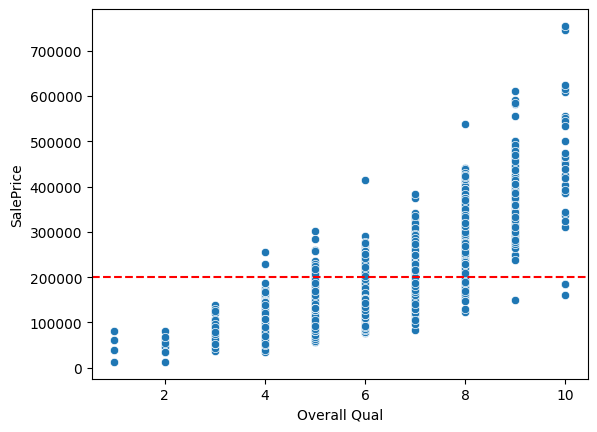

In [32]:
plt.axhline(y=200000,color='red', linestyle='--')
sns.scatterplot(x='Overall Qual', y='SalePrice', data=df)

Правый нижний - выбросы. За ~18000 качество 9 и 10, хотя обычно нидже

<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

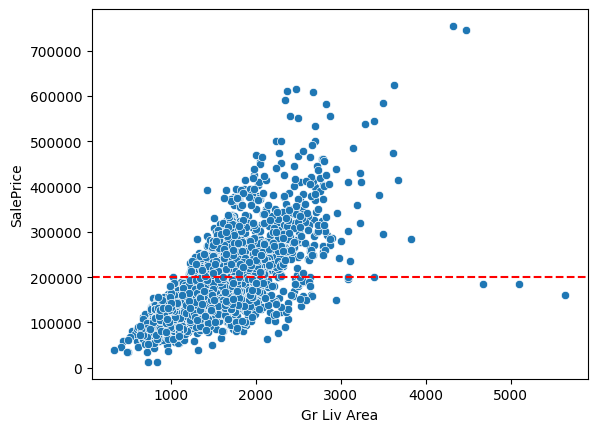

In [35]:
plt.axhline(y=200000, color='red', linestyle='--')
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

Справа внизу: большая площадь, но низкая цена. Это не соответствует трендам в данным, надо удалить. Их ОЧЕНЬ мало (3), их % маленький

In [31]:
df[(df['Overall Qual'] > 8) & (df['SalePrice'] < 200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1182,533350090,60,RL,NaN,24572,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Family,150000
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


In [38]:
df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 200000)]

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1498,908154235,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000
2180,908154195,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,Elev,17000,10,2007,New,Partial,183850
2181,908154205,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750


1182 нужно исследовать отдельно

Принимаем решение, что дома 1498б 2180б 2181 нужно удалить

In [43]:
drop_ind = df[(df['Gr Liv Area'] > 4000) & (df['SalePrice'] < 200000)].index
drop_ind

Index([1498, 2180, 2181], dtype='int64')

In [44]:
df = df.drop(drop_ind, axis=0)


<Axes: xlabel='Gr Liv Area', ylabel='SalePrice'>

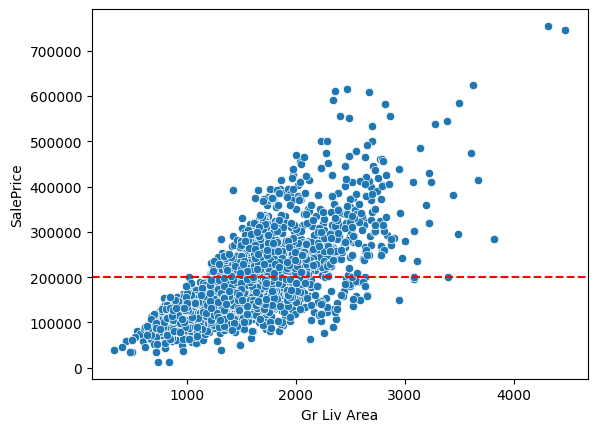

In [45]:
plt.axhline(y=200000, color='red', linestyle='--')
sns.scatterplot(x='Gr Liv Area', y='SalePrice', data=df)

Теперь более красивый график. Обищй тренд: больше площадь - больше цена

In [ ]:
#df.to_csv('my_outliers_removed_csv', index=False)

### **Missing Data**

1) **ОСТАВИТЬ**
   - Легче всего
   - Не меняем исходные данные
   - Многие алгоритмы не умеют работать с NaN
   - Часто можно аргументированно заменить данные
3) **УДАЛИТЬ**
   - Легко реализовать
   - Можно сделать на основе данных (если в колонке >90% NaN -- удаляем)
   - Потеря потенциально полезной инф-ии
   - Модели меньше пригодны для будущих данных
   - ! Всегда стоит подумать, можно ли откуда-нибудь данные подтянуть
5) **ЧЕМ-ТО ЗАМЕНИТЬ**
   - Сохраняем больше данных для обучения модели
   - Сложнее всего сделать, и можно сделать по-разному
   - Возможно получение ложных выводов

In [46]:
import pandas as pd
import numpy as np

In [118]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\03-Pandas\movie_scores.csv", 
                 keep_default_na=False,
                 na_values=['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan', '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'n/a', 'nan', 'null']
                )

In [48]:
df

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
1,NaN,NaN,NaN,NaN,NaN,NaN
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [50]:
df.isnull()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,False,False,False,False,False,False
1,True,True,True,True,True,True
2,False,False,False,False,True,True
3,False,False,False,False,False,False
4,False,False,False,False,False,False


In [51]:
df.notnull()

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,True,True,True,True,True,True
1,False,False,False,False,False,False
2,True,True,True,True,False,False
3,True,True,True,True,True,True
4,True,True,True,True,True,True


In [52]:
df.isnull().sum()

first_name          1
last_name           1
age                 1
sex                 1
pre_movie_score     2
post_movie_score    2
dtype: int64

In [57]:
df[df.pre_movie_score.notnull()]

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [55]:
df[(df.pre_movie_score.isnull()) & df.first_name.notnull()]

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
2,Hugh,Jackman,51.0,m,NaN,NaN


**Удаление данных**

In [62]:
df.dropna(thresh=2)

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [63]:
df.dropna(axis=1)

""
0
1
2
3
4


In [64]:
#subset - удаляе  только те строки/столбцы, где NaN встречается в указанных в параметре колонках
df.dropna(subset=['last_name'])

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
2,Hugh,Jackman,51.0,m,NaN,NaN
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


**Замена данных**

In [66]:
df.fillna('NEW VALUE')

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.0,m,8.0,10.0
1,NEW VALUE,NEW VALUE,NEW VALUE,NEW VALUE,NEW VALUE,NEW VALUE
2,Hugh,Jackman,51.0,m,NEW VALUE,NEW VALUE
3,Oprah,Winfrey,66.0,f,6.0,8.0
4,Emma,Stone,31.0,f,7.0,9.0


In [67]:
df['pre_movie_score'].fillna(0)

0    8.0
1    0.0
2    0.0
3    6.0
4    7.0
Name: pre_movie_score, dtype: float64

In [70]:
df['pre_movie_score'].fillna(df['pre_movie_score'].mean())

0    8.0
1    7.0
2    7.0
3    6.0
4    7.0
Name: pre_movie_score, dtype: float64

In [72]:
df.fillna(df.select_dtypes(include='number').mean())

,first_name,last_name,age,sex,pre_movie_score,post_movie_score
0,Tom,Hanks,63.00,m,8.0,10.0
1,NaN,NaN,52.75,NaN,7.0,9.0
2,Hugh,Jackman,51.00,m,7.0,9.0
3,Oprah,Winfrey,66.00,f,6.0,8.0
4,Emma,Stone,31.00,f,7.0,9.0


In [73]:
airline_tix = {'first':100,'business':np.nan,'economy-plus':50,'economy':30}

In [74]:
ser = pd.Series(airline_tix)

In [75]:
ser

first           100.0
business          NaN
economy-plus     50.0
economy          30.0
dtype: float64

Выполним интерполяцию. Видим, что чем выше класс, тем дороже цена. Линейная интерполяция: среднее суммы соседних точек

*Данные должны быть заранее упорядочены для .interpolate()*

In [76]:
ser.interpolate()

first           100.0
business         75.0
economy-plus     50.0
economy          30.0
dtype: float64

In [154]:
with open(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\Ames_Housing_Feature_Description.txt", mode='r') as f:
    print(f.read())

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [119]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\Ames_outliers_removed.csv", keep_default_na=False,
                 
                 na_values=['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan', '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'n/a', 'nan', 'null']
                )

In [92]:
#df.info()

In [120]:
df.head()

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [121]:
df = df.drop('PID', axis=1)

In [122]:
len(df.columns)

80

In [123]:
100*df.isnull().sum() / len(df)

MS SubClass        0.00000
MS Zoning          0.00000
Lot Frontage      16.74069
Lot Area           0.00000
Street             0.00000
                    ...   
Mo Sold            0.00000
Yr Sold            0.00000
Sale Type          0.00000
Sale Condition     0.00000
SalePrice          0.00000
Length: 80, dtype: float64

In [87]:
def percent_missing(my_df):
    result = 100*my_df.isnull().sum() / len(my_df)
    result = result[result > 0].sort_values()
    return result

In [124]:
percent_nan = percent_missing(df)

In [125]:
percent_nan

Total Bsmt SF      0.034165
Bsmt Unf SF        0.034165
BsmtFin SF 2       0.034165
Electrical         0.034165
BsmtFin SF 1       0.034165
Garage Area        0.034165
Garage Cars        0.034165
Bsmt Full Bath     0.068329
Bsmt Half Bath     0.068329
Mas Vnr Area       0.785787
Mas Vnr Type       0.785787
Bsmt Cond          2.733174
Bsmt Qual          2.733174
BsmtFin Type 1     2.733174
BsmtFin Type 2     2.767339
Bsmt Exposure      2.835668
Garage Type        5.363854
Garage Finish      5.432183
Garage Qual        5.432183
Garage Yr Blt      5.432183
Garage Cond        5.432183
Lot Frontage      16.740690
Fireplace Qu      48.582166
Fence             80.457807
Alley             93.235395
Misc Feature      96.412709
Pool QC           99.590024
dtype: float64

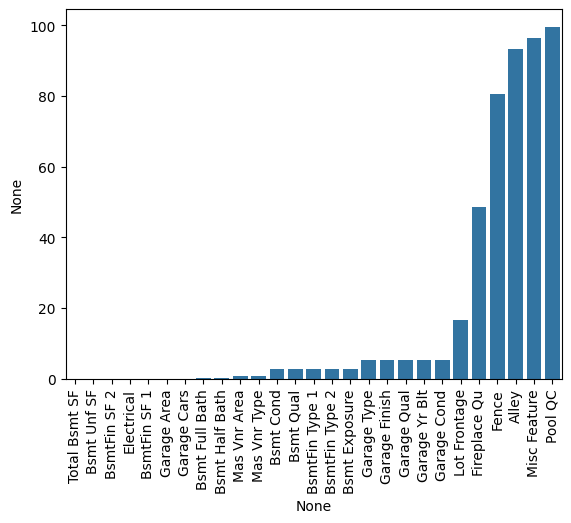

In [126]:
sns.barplot(x =percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);

Посмотрим на те признаки, где процент пропущенных значений < 1. Выбрали именно это число волевым решением

(0.0, 1.0)

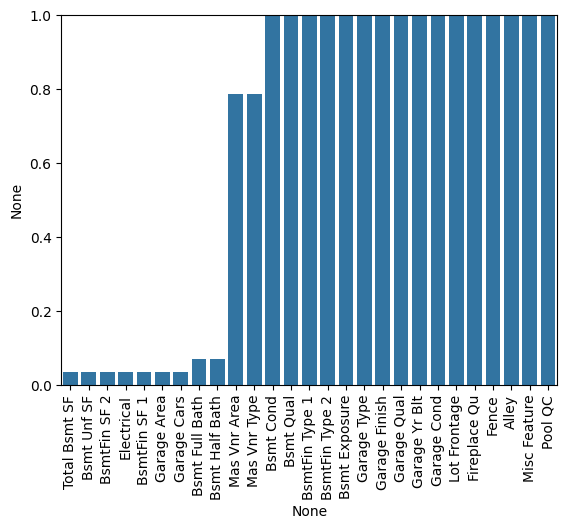

In [127]:
sns.barplot(x =percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);
plt.ylim(0,1)

In [128]:
percent_nan[percent_nan < 1].sort_values()

Total Bsmt SF     0.034165
Bsmt Unf SF       0.034165
BsmtFin SF 2      0.034165
Electrical        0.034165
BsmtFin SF 1      0.034165
Garage Area       0.034165
Garage Cars       0.034165
Bsmt Full Bath    0.068329
Bsmt Half Bath    0.068329
Mas Vnr Area      0.785787
Mas Vnr Type      0.785787
dtype: float64

In [129]:
100 / len(df) 
# 1 строка это вот столько процентов

0.0341646737273659

In [130]:
df[df.Electrical.isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1576,80,RL,73.0,9735,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,5,2008,WD,Normal,167500


In [131]:
df[df.Electrical.isnull()]['Garage Area']

1576    400.0
Name: Garage Area, dtype: float64

In [132]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [133]:
df = df.dropna(axis=0, subset=['Garage Area', 'Electrical'])
# до запуска команды узнали, что будет удалено всего 2 строки

In [134]:
percent_nan = percent_missing(df)

In [135]:
percent_nan[percent_nan < 1]
# пропал признак Garage Cars. Значит, он был в той же строке, что и Garage Area, и соотв-о, был удален

Total Bsmt SF     0.034188
Bsmt Unf SF       0.034188
BsmtFin SF 2      0.034188
BsmtFin SF 1      0.034188
Bsmt Full Bath    0.068376
Bsmt Half Bath    0.068376
Mas Vnr Area      0.786325
Mas Vnr Type      0.786325
dtype: float64

(0.0, 1.0)

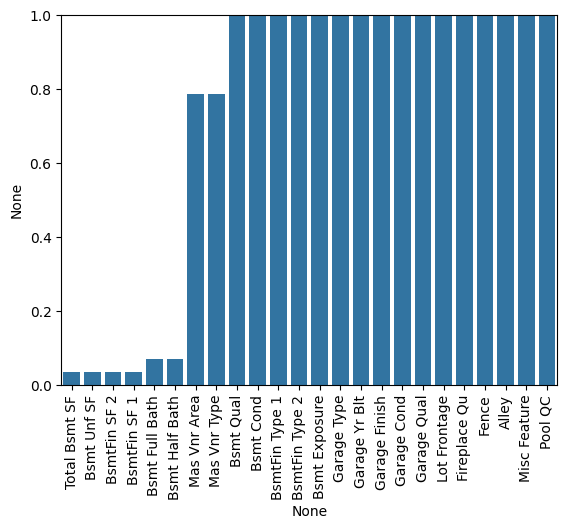

In [136]:
sns.barplot(x =percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);
plt.ylim(0,1)

In [137]:
df[df['Bsmt Half Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [138]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000
1497,20,RL,123.0,47007,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,284700


In [139]:
df[df['Bsmt Unf SF'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
1341,20,RM,99.0,5940,Pave,NaN,IR1,Lvl,AllPub,FR3,...,0,NaN,MnPrv,NaN,0,4,2008,ConLD,Abnorml,79000


In [140]:
# для числовых колонок - fillna 0
bsmt_num_cols = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF','Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath']
df[bsmt_num_cols] = df[bsmt_num_cols].fillna(0)
#  для текстовых колонок - fillna 'None'
bsmt_str_cols =  ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']
df[bsmt_str_cols] = df[bsmt_str_cols].fillna('None')

In [141]:
df[df['Bsmt Full Bath'].isnull()]

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


In [142]:
percent_nan = percent_missing(df)

(0.0, 1.0)

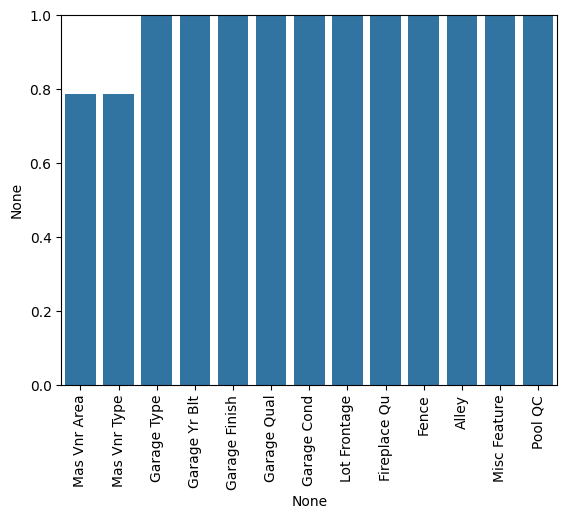

In [143]:
sns.barplot(x =percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);
plt.ylim(0,1)

In [144]:
df['Mas Vnr Type'] = df['Mas Vnr Type'].fillna('None')
# взяли None из описания данного столбца

In [145]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [147]:
percent_nan = percent_missing(df)

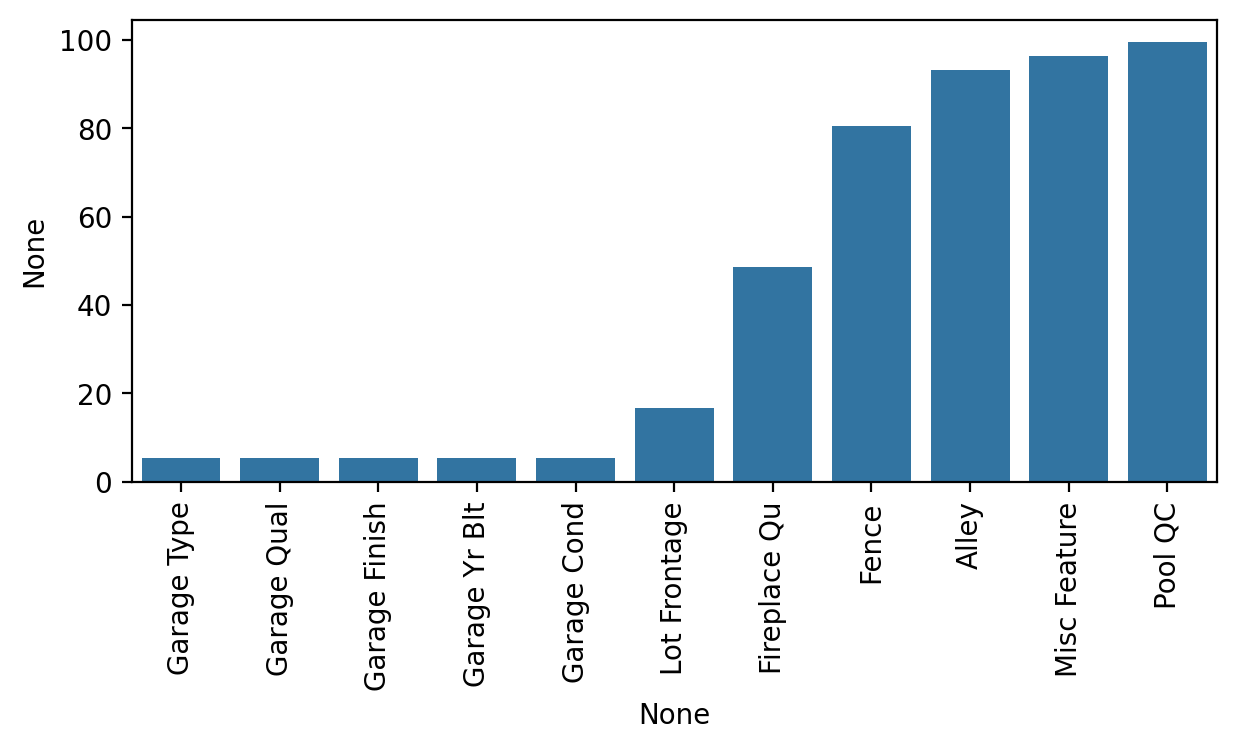

In [149]:
plt.figure(figsize=(7,3), dpi=200)
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);


In [150]:
gar_str_cols = ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

In [151]:
df[gar_str_cols] = df[gar_str_cols].fillna('None')

In [152]:
percent_nan = percent_missing(df)

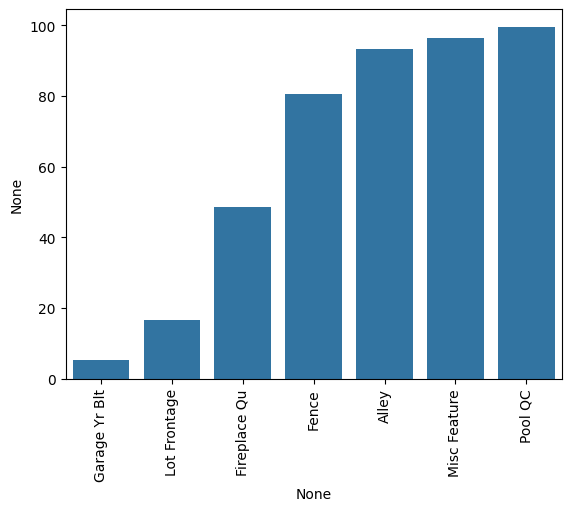

In [153]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);


GarageYrBlt: Year garage was built

Т.е. если гаража нет, то можно поставить год постройки = 0. 

In [155]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [156]:
percent_nan = percent_missing(df)

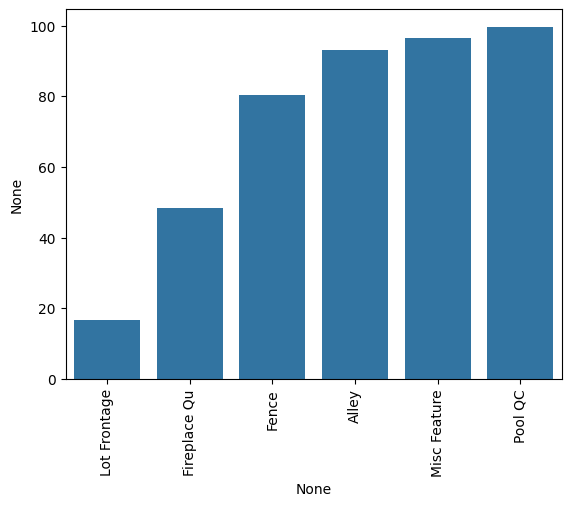

In [157]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);

Fence, Pool QC, Alley: NA= отсутствие данного элемента в доме

In [158]:
# удалим колонки с % пропусков, близким к 100%
df = df.drop(['Alley', 'Fence', 'Pool QC', 'Misc Feature'], axis=1)

In [159]:
percent_nan = percent_missing(df)

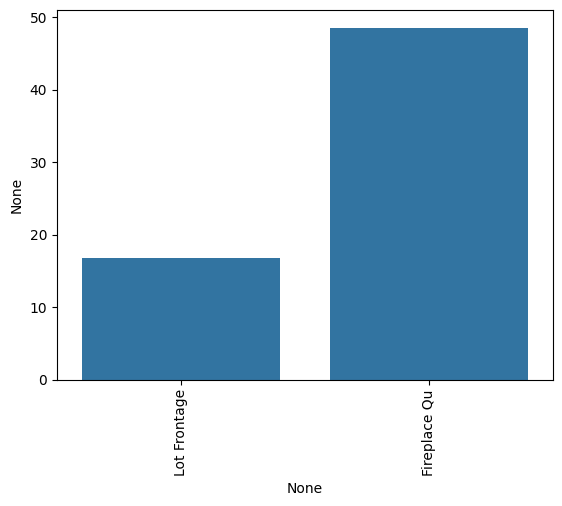

In [160]:
sns.barplot(x=percent_nan.index, y=percent_nan)
plt.xticks(rotation=90);

In [161]:
df['Fireplace Qu'].value_counts()

Fireplace Qu
Gd    741
TA    600
Fa     75
Po     46
Ex     43
Name: count, dtype: int64

In [162]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [164]:
df['Lot Frontage']
#длина дороги, прилегающей к дому

0       141.0
1        80.0
2        81.0
3        93.0
4        74.0
        ...  
2922     37.0
2923      NaN
2924     62.0
2925     77.0
2926     74.0
Name: Lot Frontage, Length: 2925, dtype: float64

Вычислим среднее значение по другим колонкам
Для дома не указан Lot Frontage: 

возьмем Neighbourhood этого дома, вычислим для Neighbourhood среднее значение Lot Frontage и возьмем его для нашего дома

<Axes: xlabel='Lot Frontage', ylabel='Neighborhood'>

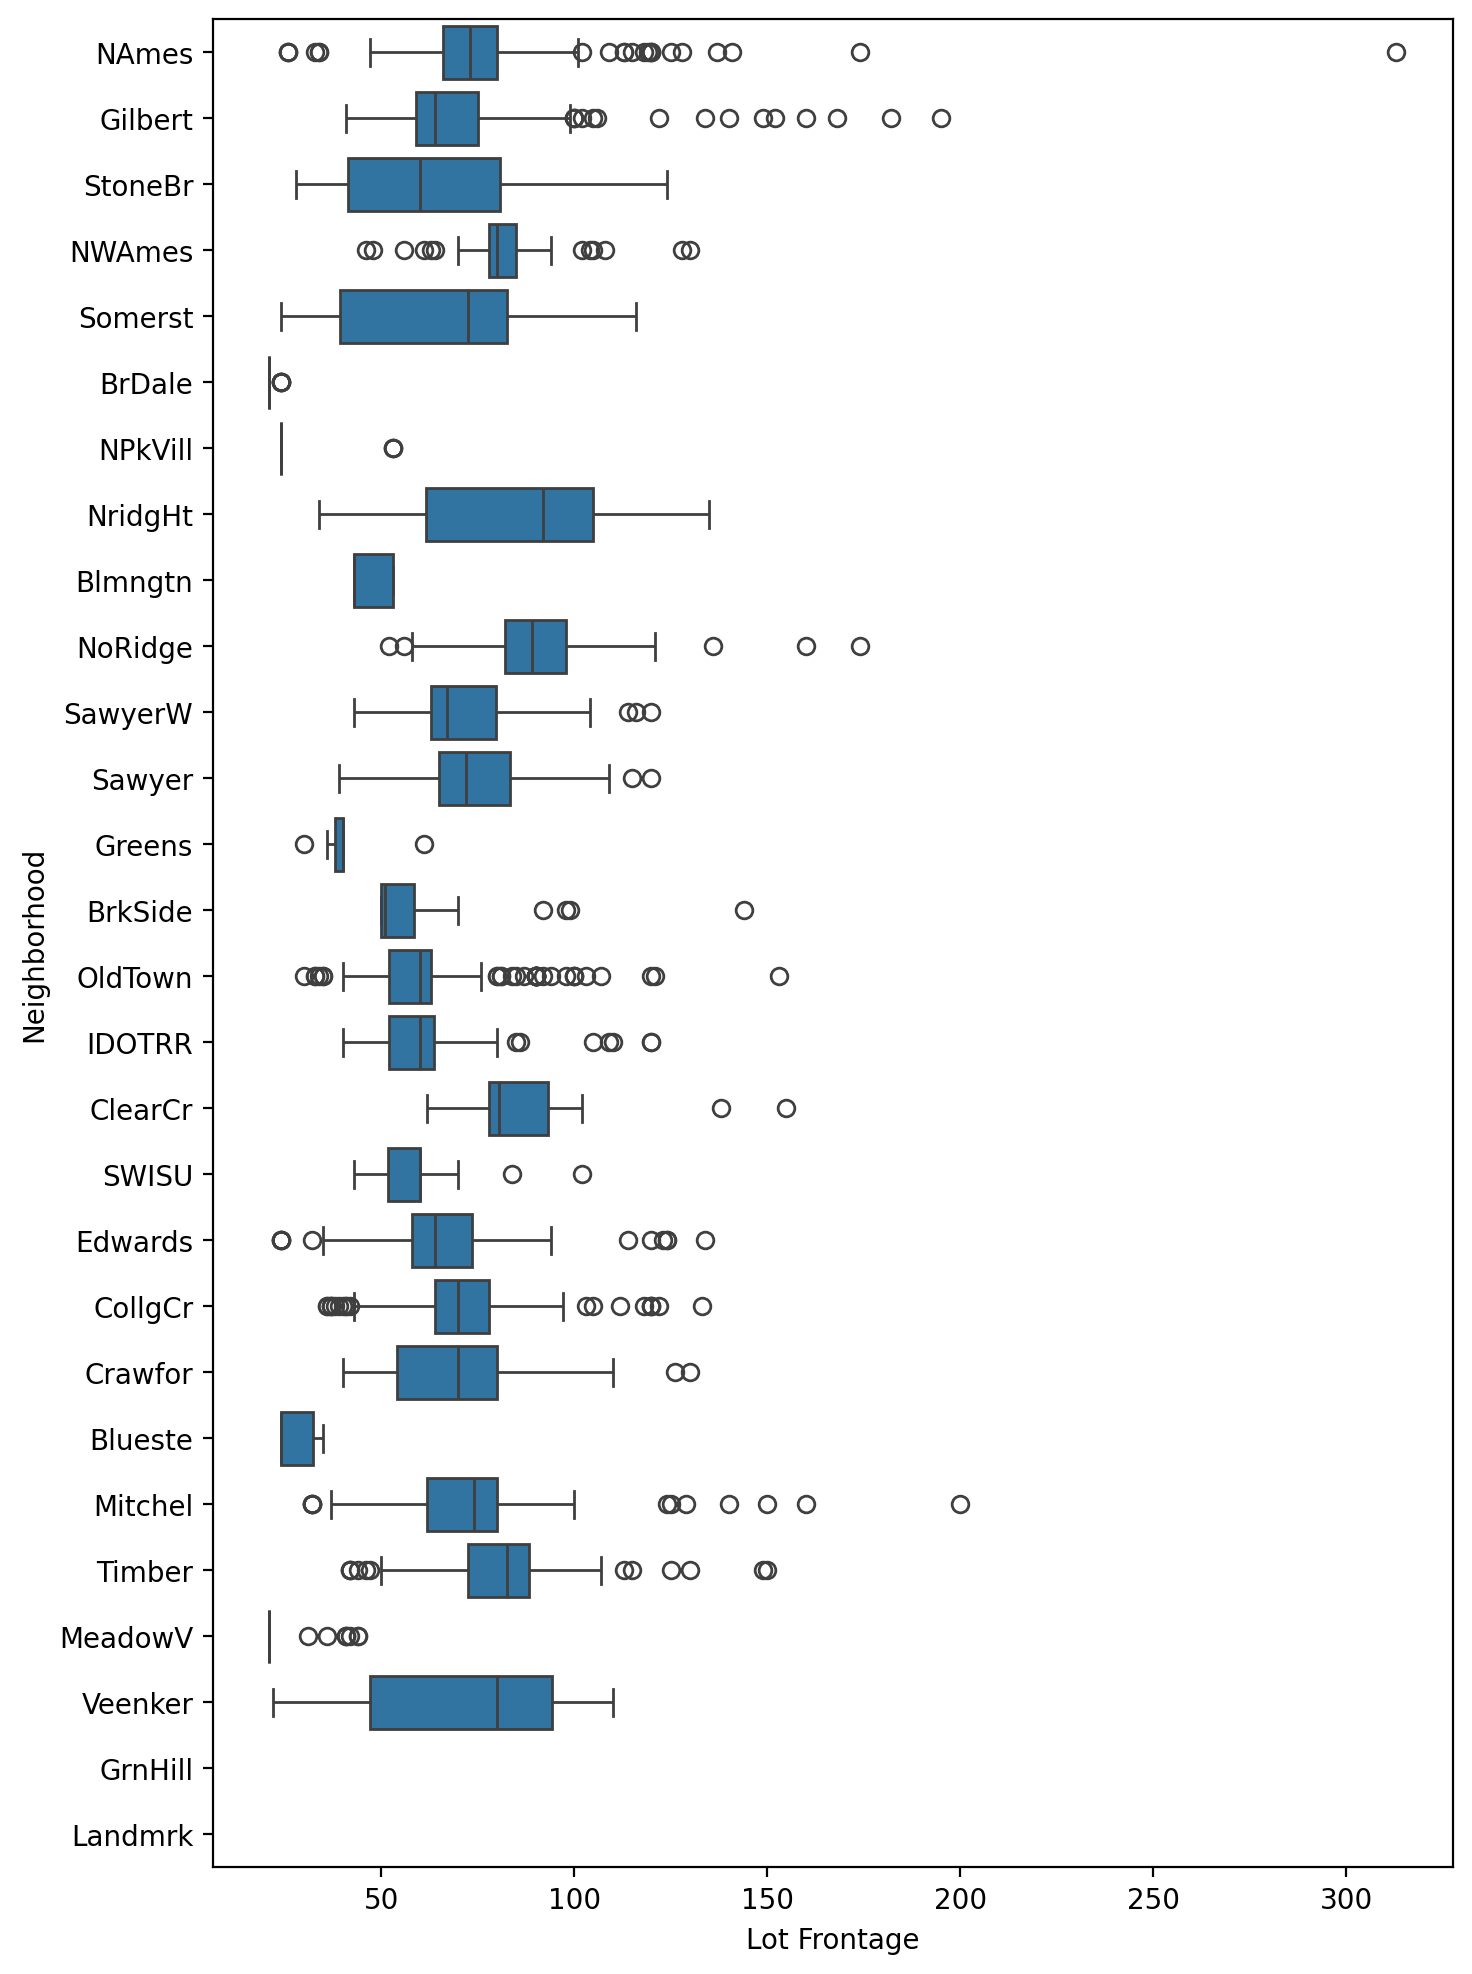

In [167]:
plt.figure(figsize=(8,12), dpi=200)
sns.boxplot(x='Lot Frontage', y='Neighborhood', data=df, orient='h')

In [168]:
df.groupby('Neighborhood')['Lot Frontage'].mean()

Neighborhood
Blmngtn    46.900000
Blueste    27.300000
BrDale     21.500000
BrkSide    55.789474
ClearCr    88.150000
CollgCr    71.336364
Crawfor    69.951807
Edwards    64.794286
Gilbert    74.207207
Greens     41.000000
GrnHill          NaN
IDOTRR     62.383721
Landmrk          NaN
MeadowV    25.606061
Mitchel    75.144444
NAmes      75.210667
NPkVill    28.142857
NWAmes     81.517647
NoRidge    91.629630
NridgHt    84.184049
OldTown    61.777293
SWISU      59.068182
Sawyer     74.551020
SawyerW    70.669811
Somerst    64.549383
StoneBr    62.173913
Timber     81.303571
Veenker    72.000000
Name: Lot Frontage, dtype: float64

In [170]:
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage'] \
                     .transform(lambda value: value.fillna(value.mean()))

In [171]:
df['Lot Frontage'].isnull().sum()

np.int64(3)

In [172]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(0)

In [173]:
df['Lot Frontage'].isnull().sum()

np.int64(0)

In [174]:
percent_nan = percent_missing(df)

In [175]:
percent_nan

Series([], dtype: float64)

**Работа с категориальными переменными**

In [195]:
df = pd.read_csv(r"C:\Users\Надежда\Downloads\UNZIP_ME_FOR_NOTEBOOKS_ML_RUS_V14\DATA\Ames_NO_Missing_Data.csv",
                keep_default_na=False,
                 na_values=['', '#N/A', '#N/A N/A', '#NA', '-1.#IND', '-1.#QNAN', '-NaN', '-nan', '1.#IND', '1.#QNAN', '<NA>', 'N/A', 'NA', 'NULL', 'NaN', 'n/a', 'nan', 'null'])

In [196]:
df.isnull().sum()

MS SubClass       0
MS Zoning         0
Lot Frontage      0
Lot Area          0
Street            0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 76, dtype: int64

MSSubClass: принимает числовые значения, но при этом признак сам по себе категориальный

In [197]:
df['MS SubClass'] = df['MS SubClass'].apply(str)

In [198]:
direction = pd.Series(['Up', 'Up', 'Down'])

In [199]:
pd.get_dummies(direction, dtype=int, drop_first=True)

,Up
0,1
1,1
2,0


Колонки дублируют друг друга, ведь если в строке указано Down=0, то очевидно, что там будет Up=1. 

Поэтому мы можем удалить одну из колонок, не потеряв при этом информацию

In [200]:
df.select_dtypes(include='object')
# str-like columns

,MS SubClass,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,20,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,TA,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
2,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Gd,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
3,20,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,TA,Typ,None,Detchd,Unf,TA,TA,Y,WD,Normal
2921,20,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,None,Attchd,Unf,TA,TA,Y,WD,Normal
2922,85,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,TA,Typ,None,None,None,None,None,Y,WD,Normal
2923,20,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [201]:
my_object_df = df.select_dtypes(include='object')
my_numeric_df = df.select_dtypes(exclude='object')

In [202]:
df_objects_dummies = pd.get_dummies(data=my_object_df,drop_first=True)

In [203]:
df_objects_dummies

,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2921,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2922,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2923,False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False


In [204]:
final_df = pd.concat([my_numeric_df,df_objects_dummies],axis=1)

In [205]:
final_df

,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,141.000000,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,...,False,False,False,False,True,False,False,False,True,False
1,80.000000,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,False,False,False,False,True,False,False,False,True,False
2,81.000000,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,False,False,False,False,True,False,False,False,True,False
3,93.000000,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,...,False,False,False,False,True,False,False,False,True,False
4,74.000000,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,37.000000,7937,6,6,1984,1984,0.0,819.0,0.0,184.0,...,False,False,False,False,True,False,False,False,True,False
2921,75.144444,8885,5,5,1983,1983,0.0,301.0,324.0,239.0,...,False,False,False,False,True,False,False,False,True,False
2922,62.000000,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,False,False,False,False,True,False,False,False,True,False
2923,77.000000,10010,5,5,1974,1975,0.0,1071.0,123.0,195.0,...,False,False,False,False,True,False,False,False,True,False


In [206]:
final_df.corr()['SalePrice'].sort_values()

Exter Qual_TA       -0.591459
Kitchen Qual_TA     -0.527461
Fireplace Qu_None   -0.481740
Bsmt Qual_TA        -0.453022
Garage Finish_Unf   -0.422363
                       ...   
Garage Cars          0.648488
Total Bsmt SF        0.660983
Gr Liv Area          0.727279
Overall Qual         0.802637
SalePrice            1.000000
Name: SalePrice, Length: 274, dtype: float64